<a href="https://colab.research.google.com/github/BridgingAISocietySummerSchools/Python-for-Data-Science-Workshop/blob/main/02_advanced_self_learning/12_scikit_learn_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 Notebook 12 — The Scikit-Learn Workflow

> **Advanced & Self-Learning Track — Notebook 12 of 14** · **Estimated time:** 70–85 min · **Difficulty:** Intermediate
>
> This track is the self-paced deep-dive of the course; the 90-minute live **Introduction Session** lives in `01_introduction/`.

The *concepts* of machine learning were the subject of the previous notebook: [`11_machine_learning_basics.ipynb`](11_machine_learning_basics.ipynb) covered what ML is, supervised vs unsupervised, features and target, train/test, the workflow loop, the metrics (accuracy, precision/recall/F1, MAE/RMSE/R²) and overfitting versus generalisation. All of that vocabulary is taken as given here. This notebook answers the professional follow-up question: **how do you run that workflow so that the number you report is true?**

Because that is the hard part. Notebook 11's loop works beautifully on a clean dataset in a single cell. The moment you add a preprocessing step, compare a few models, or tune a hyper-parameter, there are half a dozen ways to accidentally look at data you are not allowed to look at — and every one of them makes your score *better* and your model *no better at all*. Scikit-learn's design is largely an answer to that problem.

Four ideas, in order:

1. **`Pipeline`** — preprocessing that cannot leak.
2. **Cross-validation** — an evaluation that does not hang on one lucky split.
3. **`GridSearchCV`** — hyper-parameter search that keeps the test set sealed.
4. **Model inspection** — feature importance, with the caveats that make it usable.

We practise them on two end-to-end projects:

1. **Classification** — predicting the species of an iris flower from its measurements.
2. **Regression** — predicting California house prices from neighbourhood features.

## 🎯 Learning objectives

By the end of this notebook you will:

1. Follow the **scikit-learn API contract** (`fit` / `predict` / `score`) and know why every model, transformer, pipeline and search object shares it.
2. Recognise **data leakage** — having watched a leaky workflow report 91 % accuracy on data that contains no signal whatsoever.
3. Use **`Pipeline`** so that "fit on the training rows only" is enforced by the code instead of by your memory.
4. Compare models with **`cross_val_score`** on the training set, and know what a single hold-out split can and cannot tell you.
5. Keep **train / validation / test** apart while tuning with **`GridSearchCV`**, and judge whether the winner it hands you is a real improvement or noise.
6. Read every score **against a baseline** (`DummyClassifier`, `DummyRegressor`), so that "0.80" becomes a statement about the world.
7. Inspect a model with **impurity and permutation importance** — and state the caveats before anyone else does.

## ✅ Prerequisites

Notebooks 1–11 of this track — and **especially [`11_machine_learning_basics.ipynb`](11_machine_learning_basics.ipynb)**, whose vocabulary (features, target, train/test, generalisation, the metric zoo) is taken as given from here on. You will also lean on pandas ([`07_pandas_essentials.ipynb`](07_pandas_essentials.ipynb)), the cleaning habits of [`08_data_cleaning_preprocessing.ipynb`](08_data_cleaning_preprocessing.ipynb) and matplotlib ([`09_visualization_matplotlib.ipynb`](09_visualization_matplotlib.ipynb)).

⬅️ **Previous:** [`11_machine_learning_basics.ipynb`](11_machine_learning_basics.ipynb) · ➡️ **Next:** [`13_pytorch_basics.ipynb`](13_pytorch_basics.ipynb)

## 1. What this notebook adds to the loop

Notebook 11 gave you the loop: define the question → get the data → split → fit → predict → evaluate → iterate. Nothing about it changes here. What changes is that we stop trusting ourselves to execute it by hand.

The reason fits in one sentence, and it is the most important idea in this notebook:

> **Every step that learns something from your data is part of your model — including the steps that do not look like a model.**

A `StandardScaler` learns a mean and a standard deviation. A feature selector learns a ranking. A missing-value imputer learns a median. An outlier filter learns a threshold. If any of them learn from rows that later end up in your test set, then your test set is no longer unseen and the score you report is fiction. It will be a *flattering* fiction — which is exactly why nobody notices.

Pipelines, cross-validation and grid search all exist to make that mistake hard to commit.

## 2. Setup

> 🎨 The chart colours in this notebook follow the [Bridging AI & Society](https://bridgingaiandsociety.org) summer-school brand palette, defined once in the setup cell below.

In [1]:
# The "Big 4" + scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datasets
from sklearn.datasets import load_iris, fetch_california_housing

# Splitting & validation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Preprocessing & feature selection
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Pipelines
from sklearn.pipeline import Pipeline

# Models — classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Models — regression
from sklearn.linear_model import LinearRegression

# Baselines — the "do nothing" models that every score should be compared against
from sklearn.dummy import DummyClassifier, DummyRegressor

# Model inspection
from sklearn.inspection import permutation_importance

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
)

# Silence a known false-positive RuntimeWarning that NumPy's matmul emits on
# some macOS (Accelerate) builds. The computed results are unaffected, and on
# other platforms (e.g. Google Colab) the warning never fires — so this
# filter is harmless there too.
import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")

# Reproducibility
RANDOM_STATE = 42

# Friendlier plot defaults (matches NB 8)
plt.rcParams.update({
    "figure.figsize"   : (8, 5),
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# --- Bridging AI & Society course plot style -------------------------------
BAS_BLUE = "#416bcc"   # brand accent (lapis blue) — primary series
BAS_INK  = "#1c2025"   # brand ink — text/edges where needed
# supporting colours, chosen to sit well next to the lapis accent:
BAS_AMBER  = "#d9822b"   # secondary series / contrast
BAS_GREEN  = "#3a9e6e"   # "good" / positive
BAS_RED    = "#c8504f"   # "bad" / warnings / errors
BAS_PURPLE = "#7a5fb5"   # tertiary series
BAS_GREY   = "#8a919c"   # de-emphasised / reference lines
BAS_PALETTE = [BAS_BLUE, BAS_AMBER, BAS_GREEN, BAS_RED, BAS_PURPLE, BAS_GREY]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=BAS_PALETTE)
# ---------------------------------------------------------------------------

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.6.1


## 3. Project 1 — Iris classification 🌸

The **Iris** dataset is the "Hello World" of ML. 150 iris flowers, each described by 4 numeric measurements (sepal length, sepal width, petal length, petal width). Goal: predict the **species** (setosa, versicolor, virginica) from the measurements.

### 3.1 Load and explore

In [2]:
iris = load_iris()

# Move into a DataFrame so we can use pandas/seaborn-style operations
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Shape: {iris_df.shape}")
print(f"Classes: {iris.target_names.tolist()}")
iris_df.head()

Shape: (150, 5)
Classes: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Per-class counts — make sure it is balanced
print(iris_df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### 3.2 Visual exploration

A small `pairplot` is the single best first look at a tabular dataset. We will use matplotlib only (so we don't depend on seaborn for this).

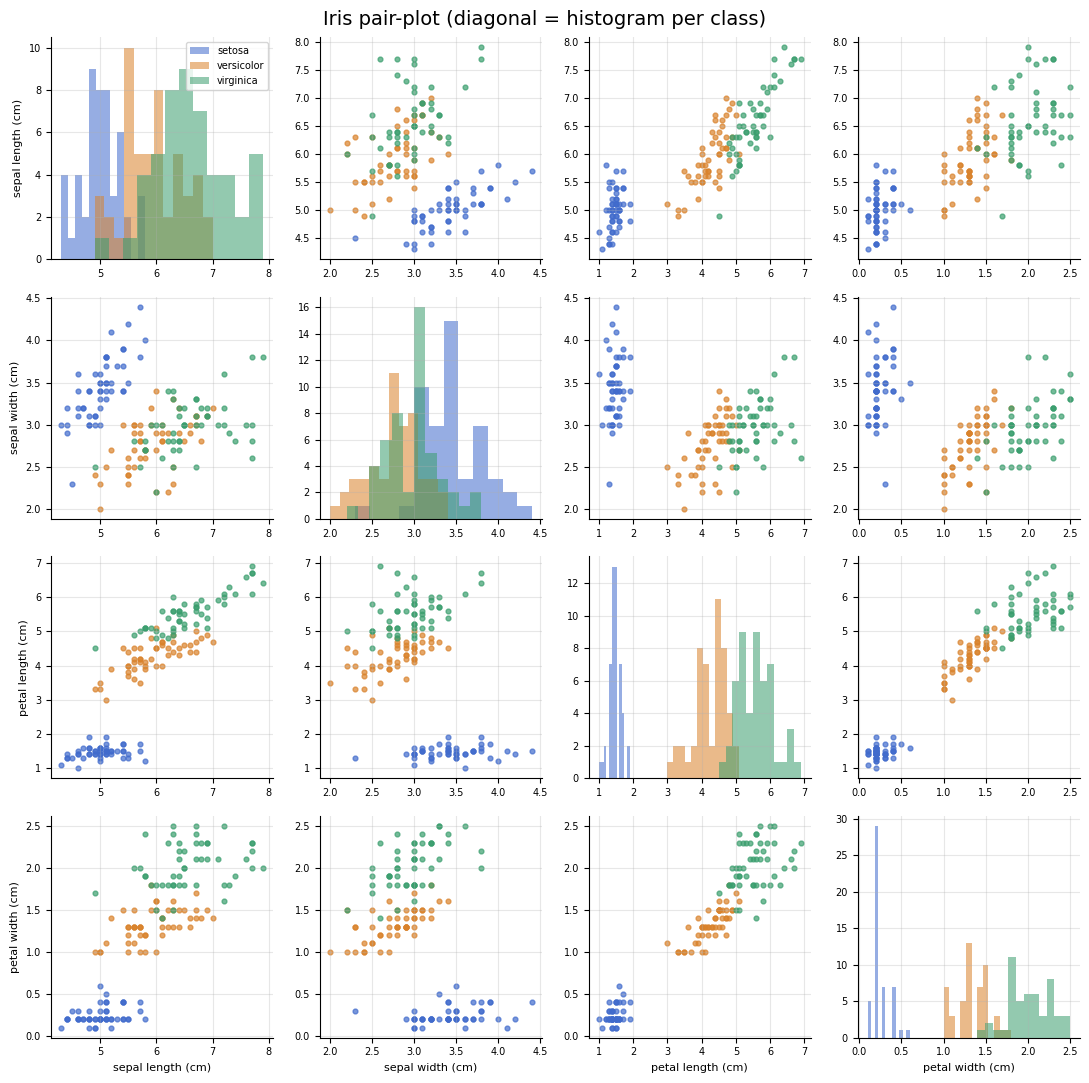

In [4]:
features = iris.feature_names
fig, axes = plt.subplots(len(features), len(features), figsize=(11, 11))
fig.suptitle("Iris pair-plot (diagonal = histogram per class)", fontsize=14)

palette = [BAS_BLUE, BAS_AMBER, BAS_GREEN]

for i in range(len(features)):
    for j in range(len(features)):
        ax = axes[i, j]
        if i == j:
            # Diagonal: histogram per class
            for k, cls in enumerate(iris.target_names):
                ax.hist(iris.data[iris.target == k, i], bins=12,
                        alpha=0.55, color=palette[k], label=cls)
            if i == 0:
                ax.legend(fontsize=7)
        else:
            for k, cls in enumerate(iris.target_names):
                ax.scatter(iris.data[iris.target == k, j],
                           iris.data[iris.target == k, i],
                           s=12, alpha=0.7, color=palette[k])
        if i == len(features) - 1:
            ax.set_xlabel(features[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(features[i], fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

**Reading the pair-plot.** *setosa* (blue) is linearly separable from the other two species — you can draw a straight line in any panel that separates blue from amber+green. *versicolor* and *virginica* overlap on most features but are well separated on **petal length / width**. That gives us a concrete, checkable expectation: a classifier should get every setosa right, and whatever mistakes it makes should sit in the versicolor/virginica overlap. We will hold that against the confusion matrix in section 3.6.

### 3.3 Train / test split

Splitting before you model is the rule from notebook 11 — this is the one function call that implements it. We hold out **20 %** of the data as a test set we won't touch until the very end. `stratify=y` makes sure the class proportions stay the same in both splits — important when classes are imbalanced.

In [5]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train : {X_train.shape}  (y distribution: {np.bincount(y_train)})")
print(f"Test  : {X_test.shape}   (y distribution: {np.bincount(y_test)})")

Train : (120, 4)  (y distribution: [40 40 40])
Test  : (30, 4)   (y distribution: [10 10 10])


### 3.4 The leak you cannot see

We now have `X_train` and `X_test`, and the rule is "never touch the test set". Almost everybody breaks it on their second project, in this exact shape:

```python
X_scaled = StandardScaler().fit_transform(X)                 # scale everything, it's tidier
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y)       # then split
```

Read the first line again. `fit_transform(X)` computes a mean and a standard deviation **over all 150 flowers**, including the 30 that are about to become the test set. Those 30 rows have now had a say in how every training row is represented. The leak is one keystroke wide and completely silent.

Let us look at what actually differs.

In [6]:
# What does the scaler learn, and does it matter where it learns it?
scaler_all   = StandardScaler().fit(X)         # WRONG: fitted on train + test together
scaler_train = StandardScaler().fit(X_train)   # RIGHT: fitted on the training rows only

print("means learned from all 150 rows  :", scaler_all.mean_.round(3))
print("means learned from the 120 train :", scaler_train.mean_.round(3))
print("stds  learned from all 150 rows  :", scaler_all.scale_.round(3))
print("stds  learned from the 120 train :", scaler_train.scale_.round(3))

shift = np.abs(scaler_all.transform(X_test) - scaler_train.transform(X_test)).max()
print(f"\nLargest difference in any transformed test value: {shift:.4f} standard deviations")

means learned from all 150 rows  : [5.843 3.057 3.758 1.199]
means learned from the 120 train : [5.842 3.048 3.77  1.205]
stds  learned from all 150 rows  : [0.825 0.434 1.759 0.76 ]
stds  learned from the 120 train : [0.837 0.447 1.761 0.759]

Largest difference in any transformed test value: 0.0679 standard deviations


Almost nothing. A few thousandths of a centimetre; the accuracy would move by zero flowers or one. **That is precisely what makes leakage dangerous** — it does not announce itself with a crash or an implausible number, so you never find out that you have a problem.

How much damage it does depends on two things: how much the leaking step learns from the data, and how few rows you have. A mean over 150 rows leaks almost nothing. A step that *searches* — a feature selector scanning thousands of columns, a hyper-parameter search, an outlier filter — leaks a great deal.

Here is the worst case, and it is not contrived: it is roughly how a run of biomedical "signatures" in the 2000s turned out to be irreproducible. Eighty patients, two thousand measured values each, and a label assigned by **coin flip**. There is nothing whatsoever to learn, so any honest method has to score about 50 %.

In [7]:
# 80 patients, 2000 measurements each, labels assigned at random -> zero signal.
rng = np.random.default_rng(0)
X_noise = rng.normal(size=(80, 2000))
y_noise = rng.integers(0, 2, size=80)

# --- The leak: pick the 20 "most predictive" columns using ALL the data, then cross-validate.
selector = SelectKBest(f_classif, k=20).fit(X_noise, y_noise)
leaky = cross_val_score(LogisticRegression(max_iter=1000),
                        selector.transform(X_noise), y_noise, cv=5)

# --- Honest: the same selection, but inside a Pipeline, so it is redone in every fold
#     using only that fold's training rows.
honest_pipe = Pipeline([
    ("select", SelectKBest(f_classif, k=20)),
    ("model",  LogisticRegression(max_iter=1000)),
])
honest = cross_val_score(honest_pipe, X_noise, y_noise, cv=5)

print(f"Leaky  (select on everything, then CV) : {leaky.mean():.3f}   folds {leaky.round(2)}")
print(f"Honest (select inside the CV folds)    : {honest.mean():.3f}   folds {honest.round(2)}")
print("\nGround truth: the labels are coin flips. The only defensible answer is 0.5.")

Leaky  (select on everything, then CV) : 0.912   folds [0.94 0.94 0.88 0.94 0.88]
Honest (select inside the CV folds)    : 0.425   folds [0.5  0.44 0.5  0.31 0.38]

Ground truth: the labels are coin flips. The only defensible answer is 0.5.


**91 % accuracy on pure noise.** The selector was allowed to see all 80 labels, so it picked the 20 columns that happened to correlate with them; by the time cross-validation ran, every fold's "unseen" rows had already helped choose the features. The honest version scores 0.43 — chance, up to the sampling noise you get from 16 rows per fold.

Nobody plans this. It happens because scaling, selecting and imputing feel like *cleaning*, and cleaning feels like something you do to the dataset before the modelling starts. So, one habit:

> **Put every fitted step inside a `Pipeline`.**

```python
pipe = Pipeline([
    ("scaler", StandardScaler()),      # any number of transformers
    ("model",  LogisticRegression()),  # exactly one estimator, last
])
pipe.fit(X_train, y_train)   # fits every step on X_train only
pipe.predict(X_test)         # applies the learned transforms, then predicts
```

A `Pipeline` is not a tidiness device. It is the object that makes "fit on the training rows only" **structurally hard to get wrong** — including inside every fold of a cross-validation and every candidate of a grid search, which is where doing it by hand is hopeless. Note also that the pipeline has `.fit`, `.predict` and `.score` itself: it *is* an estimator, so anything that accepts a model accepts a pipeline.

### 3.5 The API contract — and how to compare models with it

Every scikit-learn estimator — model, transformer, pipeline or search object — has the same shape:

```python
model = SomeModel(hyperparam=value)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score  = model.score(X_test, y_test)
```

That uniformity is why swapping a logistic regression for a random forest is a one-line change, and why `Pipeline`, `cross_val_score` and `GridSearchCV` can accept any of them without knowing what is inside.

So we can compare four models in a loop. But **not on the test set.** Picking a model by its test score is a decision made *using* the test set, and a decision is a kind of fitting: the winner's test score is then the maximum of four noisy numbers, which is optimistic by construction. We therefore compare with 5-fold cross-validation **on the training data** and keep the test set sealed for one final measurement.

A `DummyClassifier` goes into the table too. Iris has three balanced classes, so always guessing the same one scores 0.33 — that is the number a real model has to beat, and it is the difference between "0.95 is high" and "0.95 is high *for this problem*".

In [8]:
# Scale-sensitive models (logistic regression, k-NN) go inside a Pipeline with a scaler.
# Tree-based models are unaffected by monotone rescaling, so they do not need one.
candidates = {
    "Baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression":      Pipeline([("scaler", StandardScaler()),
                                          ("model", LogisticRegression(max_iter=1000,
                                                                       random_state=RANDOM_STATE))]),
    "Decision Tree":            DecisionTreeClassifier(random_state=RANDOM_STATE),
    "k-NN (k=5)":               Pipeline([("scaler", StandardScaler()),
                                          ("model", KNeighborsClassifier(n_neighbors=5))]),
    "Random Forest":            RandomForestClassifier(n_estimators=100,
                                                       random_state=RANDOM_STATE),
}

print(f"{'Model':<26}{'CV accuracy':>13}{'std':>8}")
print("-" * 47)
for name, estimator in candidates.items():
    cv = cross_val_score(estimator, X_train, y_train, cv=5)   # training data only!
    print(f"{name:<26}{cv.mean():>13.3f}{cv.std():>8.3f}")

Model                       CV accuracy     std
-----------------------------------------------
Baseline (most frequent)          0.333   0.000
Logistic Regression               0.958   0.026
Decision Tree                     0.942   0.020
k-NN (k=5)                        0.967   0.031


Random Forest                     0.950   0.017


Read that table like a professional, which means reading the third column as well.

- Every real model is far above the 0.333 baseline. The four measurements genuinely determine the species — *that* is the finding, and the baseline is what makes it one.
- The four real models span 0.942 to 0.967: **0.025 apart, while each one wobbles by 0.017 to 0.031 between folds.** They are indistinguishable on 120 training rows. Re-run the comparison with a different `random_state` and the ranking can reorder itself.
- Which is a perfectly normal result. The useful conclusion is not "pick the winner" but "the signal is strong, and model choice is not where the remaining effort belongs" — better features or more data would be.

We continue with the **random forest**, not because it won (it did not), but because it can tell us which features it used, which we want in section 3.8. Being explicit about a choice like that, instead of dressing it up as a victory, is part of the job.

### 3.6 The final measurement, and the confusion matrix

Now — once — we fit the chosen model on all 120 training rows and look at the 30 test rows. Notebook 11 explained what a confusion matrix and a `classification_report` *mean*; what follows is what to **do** with them.

Test accuracy: 0.900   (baseline: 0.333)


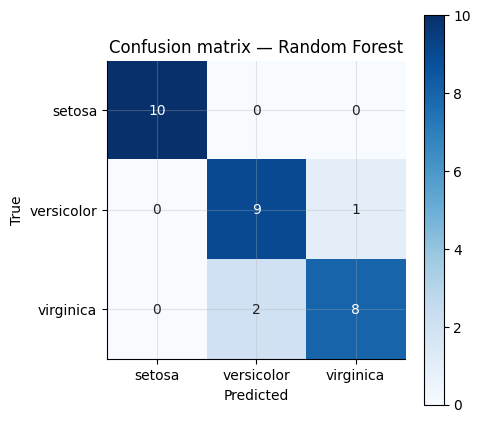


Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [9]:
# The test set is opened exactly once, here.
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"Test accuracy: {rf.score(X_test, y_test):.3f}   (baseline: 0.333)")

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), iris.target_names)
ax.set_yticks(range(3), iris.target_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix — Random Forest")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else BAS_INK)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

**What to do with this output.**

- **Read the diagonal against the `support` column.** Ten flowers per class, so **every cell in this matrix is worth 3.3 percentage points of accuracy**. The two versicolor/virginica mix-ups are the entire difference between 0.90 and 0.97. On a test set this small, do not narrate small differences as findings — including the differences between models in section 3.5.
- **Look at *which* mistake it makes, not just how many.** Every error sits in the versicolor ↔ virginica block and none involves setosa — exactly the prediction we made from the pair-plot. A model whose errors concentrate where the classes genuinely overlap is behaving sensibly; one that confused setosa with virginica would signal a bug in your code, not a hard problem.
- **Report per-class numbers, never the single accuracy.** `classification_report` gives precision, recall and F1 per class, plus `support`. Its `macro avg` (unweighted mean over classes) and `weighted avg` (weighted by support) rows diverge the moment classes are imbalanced; here they agree, because Iris is balanced.
- **Pick the metric from the consequences.** Notebook 11 made that case in full — a spam filter guards precision, a screening test guards recall. In code, the choice becomes the `scoring=` argument you hand to `cross_val_score` and `GridSearchCV` (`"f1_macro"`, `"recall"`, `"balanced_accuracy"`, …). The default `"accuracy"` is a decision too, even when you make it by not thinking.

### 3.7 Predicting new flowers

In [10]:
# Three hand-crafted measurements: [sepal_len, sepal_wid, petal_len, petal_wid]
new_flowers = np.array([
    [5.1, 3.5, 1.4, 0.2],   # looks like setosa
    [6.2, 2.8, 4.8, 1.8],   # could be either versicolor or virginica
    [7.7, 3.0, 6.1, 2.3],   # likely virginica
])

pred = rf.predict(new_flowers)
prob = rf.predict_proba(new_flowers)

for i, p in enumerate(pred):
    probs = ", ".join(f"{iris.target_names[k]}: {prob[i, k]:.0%}" for k in range(3))
    print(f"Flower {i+1}: predicted {iris.target_names[p]:<12}   ({probs})")

Flower 1: predicted setosa         (setosa: 100%, versicolor: 0%, virginica: 0%)
Flower 2: predicted virginica      (setosa: 0%, versicolor: 28%, virginica: 72%)
Flower 3: predicted virginica      (setosa: 0%, versicolor: 0%, virginica: 100%)


`predict_proba` returns the model's probability per class. Look at flower 2 — even the model is uncertain whether it is versicolor or virginica. That uncertainty is information you should expose to users.

### 3.8 Feature importance — and why it needs a health warning

A fitted random forest exposes `feature_importances_`: per feature, how much impurity it removed across all the splits of all the trees, normalised to sum to 1. It is the cheapest interpretability tool in existence and the most over-read, so we will plot it twice — once as it comes, and once after handing the forest two columns that contain nothing at all.

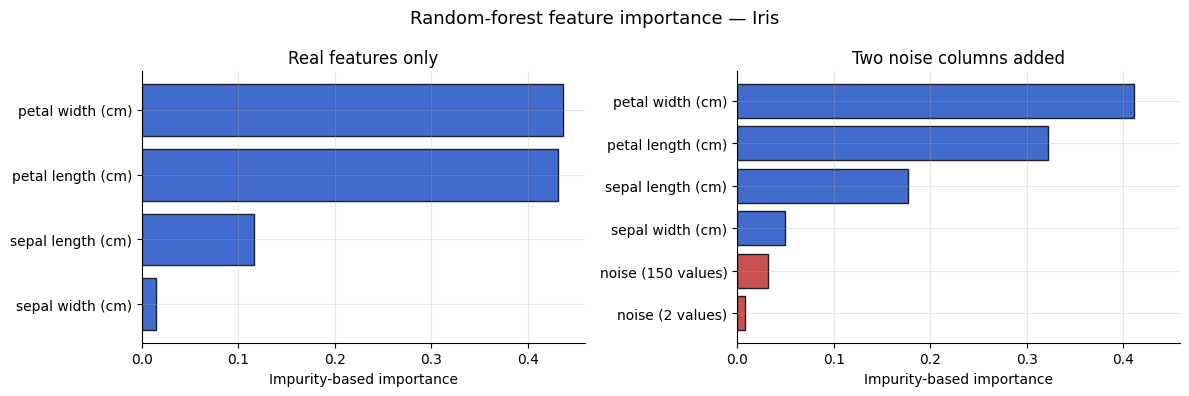

real features only:
  sepal length (cm)     0.116
  sepal width (cm)      0.015
  petal length (cm)     0.431
  petal width (cm)      0.437

with the noise columns added:
  sepal length (cm)     0.178
  sepal width (cm)      0.049
  petal length (cm)     0.322
  petal width (cm)      0.412
  noise (150 values)    0.032   <- pure noise
  noise (2 values)      0.008   <- pure noise

Test accuracy without the noise columns: 0.900
Test accuracy with    the noise columns: 0.933


In [11]:
# Left: the four real features. Right: the same forest after we add two columns of
# pure noise — one with 150 distinct values, one with only 2.
rng = np.random.default_rng(0)
X_plus = np.column_stack([
    iris.data,
    rng.normal(size=len(iris.data)),            # noise, 150 distinct values
    rng.integers(0, 2, size=len(iris.data)),    # noise, 2 distinct values
])
names_plus = iris.feature_names + ["noise (150 values)", "noise (2 values)"]

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_plus, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
rf_plus = RandomForestClassifier(n_estimators=100,
                                 random_state=RANDOM_STATE).fit(Xp_train, yp_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, names, imps, title in [
    (axes[0], iris.feature_names, rf.feature_importances_, "Real features only"),
    (axes[1], names_plus, rf_plus.feature_importances_, "Two noise columns added"),
]:
    names = np.array(names)
    order = np.argsort(imps)
    colours = [BAS_RED if "noise" in n else BAS_BLUE for n in names[order]]
    ax.barh(names[order], np.array(imps)[order], color=colours, edgecolor=BAS_INK)
    ax.set_title(title)
    ax.set_xlabel("Impurity-based importance")
fig.suptitle("Random-forest feature importance — Iris", fontsize=13)
plt.tight_layout()
plt.show()

print("real features only:")
for name, imp in zip(iris.feature_names, rf.feature_importances_):
    print(f"  {name:<22}{imp:.3f}")
print("\nwith the noise columns added:")
for name, imp in zip(names_plus, rf_plus.feature_importances_):
    print(f"  {name:<22}{imp:.3f}" + ("   <- pure noise" if "noise" in name else ""))
print(f"\nTest accuracy without the noise columns: {rf.score(X_test, y_test):.3f}")
print(f"Test accuracy with    the noise columns: {rf_plus.score(Xp_test, yp_test):.3f}")

The left panel confirms the pair-plot: petal width and petal length take about 87 % of the credit between them. The right panel is the health warning. Three caveats, which you should be able to recite before you quote a number like this to anybody.

**1. Impurity importance never reports zero, and it is biased towards columns with many distinct values.** Our two extra columns are random numbers, and the test accuracy did not suffer for them (it moved by a single flower, in the flattering direction — itself a reminder of how little a 30-row test set can settle). The forest nevertheless handed them 3.2 % and 0.8 % of the credit — and the noise column with 150 distinct values collected about **four times** as much as the one with two. There is the bias in a single comparison: more distinct values means more candidate split points, means more chances to fit noise, means more apparent importance. Any real dataset with an ID-like column, a timestamp, or a high-cardinality category shows the same effect — and there it will not be labelled "noise".

**2. Correlated features split the credit.** Petal length and petal width are strongly correlated and nearly interchangeable here, so each shows roughly half of what "petal size" as a concept is really worth. A crucial feature can look minor purely because it has a twin in the table.

**3. Importance is not causation.** It describes what *this fitted model* leaned on, in *this* dataset. It is not evidence that petal width makes a flower a virginica, and it would not survive the flowers being measured differently. Section 4.8 introduces a better-behaved tool (permutation importance) on the housing data.

## 4. Project 2 — California housing 🏠

Now a **regression** task: predict the *median house value* of a California census block from neighbourhood features. (`fetch_california_housing` replaced the old Boston housing dataset, which scikit-learn removed on ethical grounds — one of its features encoded the proportion of Black residents per town.)

**Watch what stays the same.** Notebook 11 told you that classification and regression are one problem with two target types. Here is what that means in code: the whole section below is the section above with four substitutions.

|                | Classification (Iris)                     | Regression (housing)                         |
|----------------|-------------------------------------------|----------------------------------------------|
| **split**      | `train_test_split(..., stratify=y)`       | `train_test_split(...)` — nothing to stratify |
| **estimator**  | `RandomForestClassifier`                  | `RandomForestRegressor`                      |
| **baseline**   | `DummyClassifier`                         | `DummyRegressor`                             |
| **evaluate**   | `accuracy_score`, `confusion_matrix`      | `mean_absolute_error`, `r2_score`            |
| **inspect**    | `feature_importances_`                    | `feature_importances_`                       |

`fit`, `predict`, `score`, `Pipeline`, `cross_val_score`, `GridSearchCV`: identical, character for character. That is what the API contract buys you — you learn the rhythm once.

In [12]:
cal = fetch_california_housing()

cal_df = pd.DataFrame(cal.data, columns=cal.feature_names)
cal_df["price"] = cal.target   # in units of $100,000

print(f"Shape  : {cal_df.shape}")
print("Target : median house value (in units of $100,000)")
cal_df.head()

Shape  : (20640, 9)
Target : median house value (in units of $100,000)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
cal_df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


### 4.1 Visual sanity check

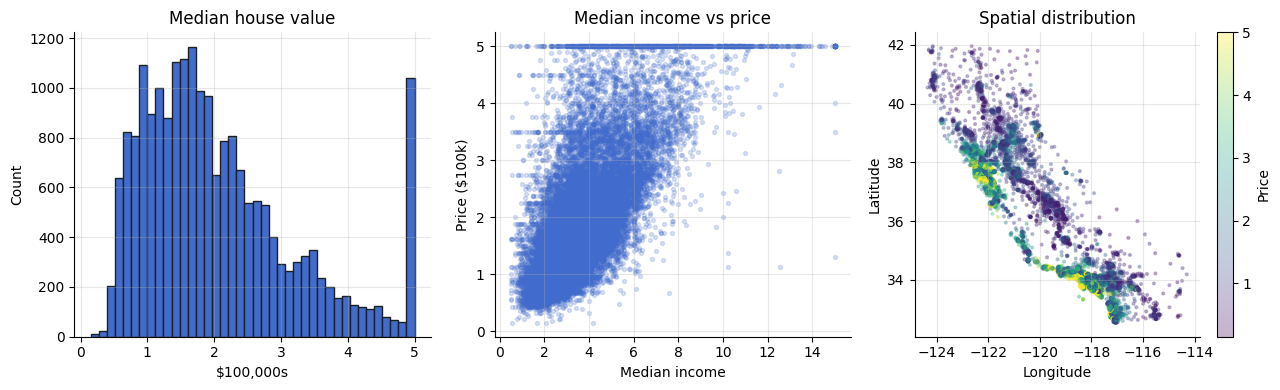

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Target distribution
axes[0].hist(cal_df["price"], bins=40, color=BAS_BLUE, edgecolor=BAS_INK)
axes[0].set_title("Median house value")
axes[0].set_xlabel("$100,000s")
axes[0].set_ylabel("Count")

# Median income vs price — should be strong
axes[1].scatter(cal_df["MedInc"], cal_df["price"], alpha=0.2, s=8, color=BAS_BLUE)
axes[1].set_title("Median income vs price")
axes[1].set_xlabel("Median income")
axes[1].set_ylabel("Price ($100k)")

# Geo-spatial peek (rough!): lon/lat coloured by price.
# "viridis" rather than "Blues" here: 20 000 faint points need a map whose
# low end is still visible, otherwise the cheap areas disappear entirely.
sc = axes[2].scatter(cal_df["Longitude"], cal_df["Latitude"],
                     c=cal_df["price"], cmap="viridis", alpha=0.3, s=4)
axes[2].set_title("Spatial distribution")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes[2], label="Price")

plt.tight_layout()
plt.show()

**Observations.**

- Prices are clipped at the top (note the spike near 5 — that's an artefact of the dataset, not nature).
- *Median income* and *price* are clearly positively correlated.
- The spatial map roughly outlines California: high-price clusters around the Bay Area and Los Angeles.

### 4.2 Train / test split, and the number to beat

No `stratify` this time: the target is continuous, so there are no class proportions to preserve.

And before any model at all, the baseline. **What does "always predict the training mean" achieve?** For regression that is what R² is defined against, so its R² will land on ~0 by construction — but its **MAE is the number that makes everything below interpretable**, because it is denominated in dollars.

In [15]:
X = cal.data
y = cal.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape},  Test: {X_test.shape}")

# The do-nothing baseline: ignore the features, always predict the training mean.
baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
y_base = baseline.predict(X_test)
mae_base = mean_absolute_error(y_test, y_base)

print(f"\nBaseline — always predict the training mean (${y_train.mean() * 100_000:,.0f}):")
print(f"  MAE  = {mae_base:.3f}   (i.e. off by ${mae_base * 100_000:,.0f} on a typical block)")
print(f"  RMSE = {mean_squared_error(y_test, y_base) ** 0.5:.3f}")
# Very slightly below 0: the *training* mean is not exactly the test mean.
print(f"  R²   = {r2_score(y_test, y_base):.4f}")

Train: (16512, 8),  Test: (4128, 8)

Baseline — always predict the training mean ($207,195):
  MAE  = 0.906   (i.e. off by $90,607 on a typical block)
  RMSE = 1.145
  R²   = -0.0002


### 4.3 The first pipeline — scaler + linear regression

Look at `describe()` above: median income runs from 0.5 to 15, population from 3 to 35 682. A linear model's coefficients and every distance-based model are at the mercy of those scales, so we standardise — and after section 3.4 we know that the scaler belongs **inside a `Pipeline`**, where it can only ever see the training rows of whatever it is being fitted on.

In [16]:
pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression()),
])

pipe_linear.fit(X_train, y_train)
y_pred = pipe_linear.predict(X_test)

print(f"{'':<12}{'MAE':>8}{'RMSE':>8}{'R²':>8}")
print("-" * 36)
for label, y_hat in [("Baseline", y_base), ("Linear", y_pred)]:
    print(f"{label:<12}{mean_absolute_error(y_test, y_hat):>8.3f}"
          f"{mean_squared_error(y_test, y_hat) ** 0.5:>8.3f}"
          f"{r2_score(y_test, y_hat):>8.3f}")

                 MAE    RMSE      R²
------------------------------------
Baseline       0.906   1.145  -0.000
Linear         0.533   0.746   0.576


**Is R² = 0.576 good?** The question has no answer in the abstract, which is precisely why we printed the baseline next to it. Compare the two rows:

- **MAE 0.533 against the baseline's 0.906.** In the units that matter, the model's typical miss is **$53,300**, where guessing the mean misses by **$90,600** — it has removed about 41 % of the average error. Real and useful; nowhere near good enough to price a house.
- **RMSE 0.746 is a lot larger than MAE 0.533.** RMSE ≥ MAE always, and the size of the gap is a signal: the errors are not evenly sized, there is a tail of badly missed blocks. Tails are worth chasing — part of this one is the blocks whose value was capped at $500,000 (the spike in the histogram above), which no model can predict.
- **R² 0.576**: the model accounts for a little over half the variance in block values. The other 44 % is either structure a straight line cannot express (section 4.4) or simply not present in these eight columns.

Notebook 11 defines MAE, RMSE and R² if any of them feels shaky. What this section adds is the habit: **never print a metric without a baseline beside it.**

### 4.4 A stronger model — random forest

Random forests fit non-linear patterns and interactions out of the box.

In [17]:
pipe_rf = Pipeline([
    ("scaler", StandardScaler()),       # not strictly needed for trees, but harmless
    ("model",  RandomForestRegressor(n_estimators=80, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)),
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

print("Random Forest:")
print(f"  MAE  = {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"  RMSE = {mean_squared_error(y_test, y_pred_rf) ** 0.5:.3f}")
print(f"  R²   = {r2_score(y_test, y_pred_rf):.3f}")

Random Forest:
  MAE  = 0.334
  RMSE = 0.512
  R²   = 0.800


Much better — and worth restating in the same currency. The typical miss drops from **$53,300 (linear)** to **$33,400 (forest)** against the baseline's **$90,600**, and R² rises from 0.576 to 0.800. The forest has found structure the straight line could not express: interactions and thresholds, such as "income matters far more inside a coastal metro than in the Central Valley".

Two sentences of honesty go with that number. R² = 0.800 still means a typical error of **$33,400 on blocks whose average value is $207,000** — a tool for ranking neighbourhoods, not for valuing a house. And a random forest cannot extrapolate: it predicts by averaging training rows, so for a block richer than anything it was trained on it will confidently return the richest average it has ever seen.

### 4.5 Predicted vs actual — a diagnostic plot

The single best regression-debugging chart: plot predicted values against true ones. A perfect model lies on the diagonal.

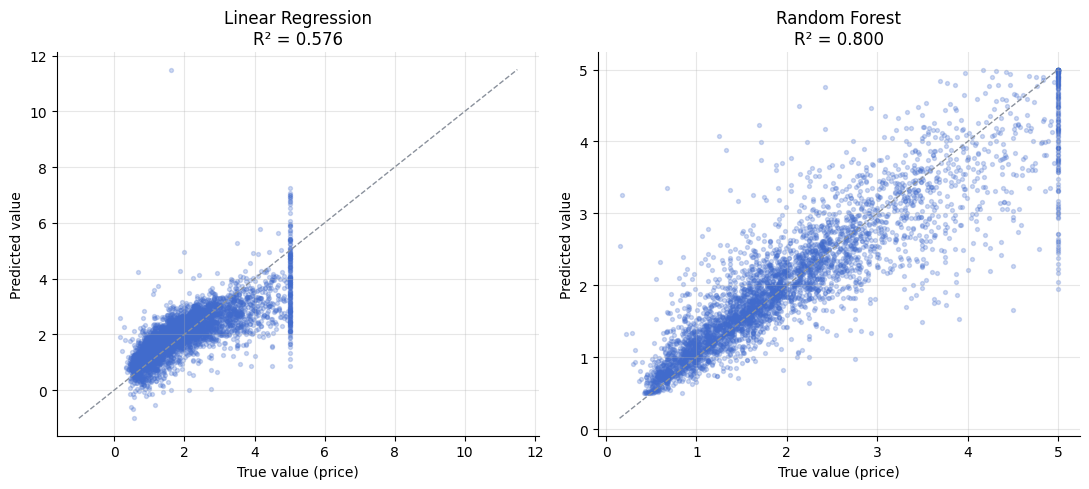

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, y_hat, name in [(axes[0], y_pred,    "Linear Regression"),
                         (axes[1], y_pred_rf, "Random Forest")]:
    ax.scatter(y_test, y_hat, alpha=0.25, s=8)
    lim = [min(y_test.min(), y_hat.min()), max(y_test.max(), y_hat.max())]
    ax.plot(lim, lim, color=BAS_GREY, linestyle="--", linewidth=1)
    ax.set_xlabel("True value (price)")
    ax.set_ylabel("Predicted value")
    ax.set_title(f"{name}\nR² = {r2_score(y_test, y_hat):.3f}")

plt.tight_layout()
plt.show()

### 4.6 Cross-validation — one number instead of one sample

The 0.800 above is a measurement on 4 128 particular rows. Split differently and you get a different number; on a small dataset, a *very* different one. `cross_val_score` gives you `k` measurements instead of one by rotating which fold is held out, and the spread across them tells you how far to trust your single number.

Note what it is *for*. Cross-validation is for **choices** — comparing models, tuning hyper-parameters — and it runs on the **training** data. The hold-out test set is for the single **report** at the end. Doing it the other way round is how people end up publishing numbers they cannot reproduce.

One practical trap: for regression, `cross_val_score` uses plain `KFold`, which does **not** shuffle — it slices the rows in the order they arrive. That is fine here because `train_test_split` already shuffled `X_train`. On a file sorted by date or region it is not fine at all: the folds become systematically different from one another and the scores collapse for reasons that have nothing to do with your model. When the rows have a time or group structure, `TimeSeriesSplit` and `GroupKFold` exist for exactly that.

In [19]:
# Training data only — the test set stays sealed.
scores = cross_val_score(pipe_rf, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)

print(f"3-fold R² scores : {scores.round(3)}")
print(f"Mean ± std       : {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Single hold-out  : {r2_score(y_test, y_pred_rf):.3f}   (section 4.4, for comparison)")

3-fold R² scores : [0.798 0.798 0.799]
Mean ± std       : 0.798 ± 0.000
Single hold-out  : 0.800   (section 4.4, for comparison)


Three folds, three nearly identical scores, and the single hold-out's 0.800 sits right on top of them. With 16 512 training rows that agreement is expected — but it is worth confirming rather than assuming, because on a 200-row dataset three folds routinely disagree by 0.05 or more, and reporting a single split there means reporting a coin flip.

Cross-validation costs `k` times as much compute as one fit. That is the whole trade, and it is nearly always worth paying.

### 4.7 Hyper-parameter tuning with `GridSearchCV`, honestly

"Is 150 trees better than 80? Should the trees be deeper?" `GridSearchCV` answers by brute force: for every combination in the grid it runs a `k`-fold cross-validation on the training data, then keeps the combination with the best mean.

Two things to be clear-eyed about.

**The cost multiplies.** The grid below has 2 × 2 = 4 combinations at `cv=2`: eight model fits, plus one refit of the winner on the whole training set. Nine fits. Add one more hyper-parameter with three values and move to `cv=5` and you are at 61 fits — for no additional information about the world, just a finer grid. `RandomizedSearchCV` samples from the grid instead of exhausting it, and is the better default as soon as the grid stops being tiny.

**Three splits, not two.** Inside `grid.fit(X_train, y_train)`, each fold's held-out part acts as a **validation set**: it is used to *choose*. `best_score_` is therefore a maximum over four attempts, and maxima are optimistic. The **test set** is a third thing that nothing in the search has seen, which is the only reason `grid.score(X_test, y_test)` means anything at all. Pass `X_train` to `fit`, never `X`.

In [20]:
param_grid = {
    "model__n_estimators": [80, 150],
    "model__max_depth":    [15, None],
}

# Small grid + cv=2 keeps this to a few seconds. On a real project: cv=5 and a wider grid.
grid = GridSearchCV(pipe_rf, param_grid, cv=2, n_jobs=-1, scoring="r2")
grid.fit(X_train, y_train)          # training data only

n_combos = len(grid.cv_results_["params"])
print(f"{n_combos} combinations x cv=2 = {n_combos * 2} fits, plus 1 refit of the winner\n")

results = pd.DataFrame(grid.cv_results_)[[
    "param_model__n_estimators", "param_model__max_depth",
    "mean_test_score", "std_test_score", "rank_test_score",
]].sort_values("rank_test_score")
print(results.to_string(index=False))

print(f"\nBest params : {grid.best_params_}")
print(f"Best CV R²  : {grid.best_score_:.3f}   <- validation score; this is what chose the winner")
print(f"Test  R²    : {grid.score(X_test, y_test):.3f}   <- reported once, and it chose nothing")

4 combinations x cv=2 = 8 fits, plus 1 refit of the winner

 param_model__n_estimators param_model__max_depth  mean_test_score  std_test_score  rank_test_score
                       150                   None         0.789036        0.004899                1
                       150                     15         0.788222        0.004934                2
                        80                   None         0.787260        0.005674                3
                        80                     15         0.786358        0.005880                4

Best params : {'model__max_depth': None, 'model__n_estimators': 150}
Best CV R²  : 0.789   <- validation score; this is what chose the winner
Test  R²    : 0.806   <- reported once, and it chose nothing


Now read the table, not just the winner.

The four combinations score **0.786, 0.787, 0.788, 0.789** — a spread of 0.003 — while each one's own fold-to-fold standard deviation is around 0.005. The differences between the candidates are smaller than the noise in measuring them. `GridSearchCV` always returns a winner and has no way of telling you that the winner is not meaningfully better than the loser. Nine model fits bought us a ranking of noise.

That is the *normal* outcome of tuning a random forest, and it is useful to know before you spend a weekend on it. Hyper-parameters matter enormously for some models — regularisation strength for a linear model, `max_depth` for a single tree, learning rate for anything gradient-based — and hardly at all for a well-defaulted ensemble. The usual order of returns in applied ML is: better data → better features → the right model family → hyper-parameters, last and least.

One more thing worth noticing: the test R² (0.806) came out *above* the best validation score (0.789). Tuned models do not always look worse on the test set — each validation fold trains on only half the training data, which handicaps it. The point of keeping the splits apart is not that the test number is lower. It is that the test number is **unbiased**.

### 4.8 Which features matter? Two answers

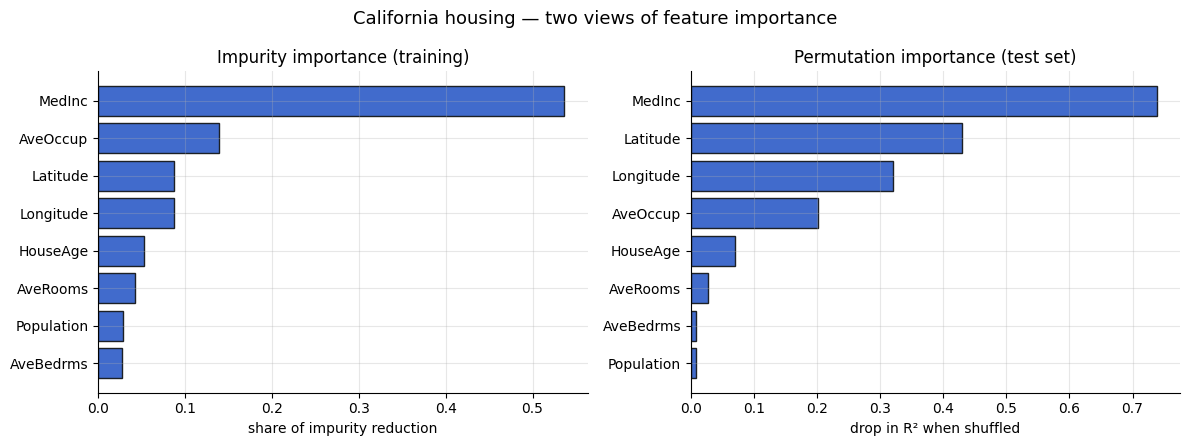

feature       impurity  permutation
-----------------------------------
MedInc           0.536        0.738
Latitude         0.088        0.430
Longitude        0.087        0.321
AveOccup         0.139        0.202
HouseAge         0.053        0.069
AveRooms         0.042        0.027
AveBedrms        0.027        0.009
Population       0.028        0.008


In [21]:
# Answer 1: impurity importance — free, computed during training, biased (section 3.8).
impurity = pipe_rf.named_steps["model"].feature_importances_

# Answer 2: permutation importance — shuffle one column of the *test* set and measure
# how far R² falls. It asks about held-out performance instead of training-time splits,
# and it works on any fitted estimator, pipelines included.
perm = permutation_importance(pipe_rf, X_test, y_test, n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1)

names = np.array(cal.feature_names)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, values, title, xlabel in [
    (axes[0], impurity, "Impurity importance (training)", "share of impurity reduction"),
    (axes[1], perm.importances_mean, "Permutation importance (test set)", "drop in R² when shuffled"),
]:
    order = np.argsort(values)
    ax.barh(names[order], values[order], color=BAS_BLUE, edgecolor=BAS_INK)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
fig.suptitle("California housing — two views of feature importance", fontsize=13)
plt.tight_layout()
plt.show()

print(f"{'feature':<12}{'impurity':>10}{'permutation':>13}")
print("-" * 35)
for i in np.argsort(perm.importances_mean)[::-1]:
    print(f"{names[i]:<12}{impurity[i]:>10.3f}{perm.importances_mean[i]:>13.3f}")

> 💡 **The two answers disagree, and the disagreement is the lesson.** Impurity importance ranks `AveOccup` second (0.139), with the two coordinates third and fourth (0.088, 0.087). Permutation importance — which asks the honest question, "how much test-set R² do I lose if this column is destroyed?" — puts **`Latitude` (0.43) and `Longitude` (0.32) far above `AveOccup` (0.20)**. Geography is doing much more work than the training-time view suggested. Both methods agree that `MedInc` leads by a distance, which is why we can believe that part.
>
> Prefer permutation importance on held-out data whenever the answer matters: it is model-agnostic and it is not fooled by high-cardinality columns. It has its own blind spot, though — with two strongly correlated features, shuffling either one alone changes little, because the model leans on the twin, so both can look unimportant.
>
> And neither number is causal. "`MedInc` has importance 0.74" does **not** mean that raising a neighbourhood's median income by one unit raises its house values by 0.74 of anything. It means this particular forest, fitted to 1990 California, could not predict well without that column.

### 4.9 What this model does not license

We have a model with an R² of 0.80. This is the point where a project either stays honest or stops being one. Four limits, specific to *this* model rather than to machine learning in general:

- **It predicts blocks, not houses.** Every row is a census block group of roughly 600–3 000 people and the target is a *median*. A prediction of $250,000 is a statement about the middle of a neighbourhood; it says nothing about any particular house in it. Applying a block-level model to an individual is the ecological fallacy, and it is the most common way a model like this gets misused.
- **It predicts 1990.** These are 1990 census figures. The relationships it learned are a snapshot of one state at one moment, and nothing in the fit knows that thirty-odd years have passed.
- **`Latitude` and `Longitude` are proxies.** They are the second and third most important features by permutation importance: the model has learned "where" very well. But the geography of 1990 Californian housing also encodes decades of redlining and segregation. A model that uses location to predict value will reproduce that history faithfully — and if such a model is used to *set* prices, price loans, or target investment, it converts a record of past discrimination into a forecast that helps sustain it. The model is not wrong about the correlation; it is silent about where the correlation came from, and that silence is the danger.
- **The top of the range is missing.** Values were capped at $500,000, so the model cannot represent expensive blocks at all — a limitation completely invisible in the aggregate R².

None of this makes the model useless. It makes its uses specific. *"Which neighbourhoods look under-valued relative to their features, so that we can go and look?"* is a fair question to put to it. *"What should this family pay for this house?"* is not. Writing that distinction down — a **model card**, in the current jargon — costs one paragraph, and it is the difference between a tool and a liability.

## 5. Common ML pitfalls (and how to avoid them)

| Pitfall                                                | Symptom                                       | Fix                                                    |
|--------------------------------------------------------|-----------------------------------------------|--------------------------------------------------------|
| **Data leakage** through preprocessing (§3.4)          | suspiciously good score, no error message     | Put every fitted step inside a `Pipeline`               |
| Training on the test set                               | unrealistically high accuracy                 | Never call `.fit()` on data you will evaluate on        |
| Choosing a model by its test score (§3.5)              | the winner cannot be reproduced               | Compare with `cross_val_score` on the training set      |
| Tuning hyperparameters on the test set (§4.7)          | optimistic generalisation estimate            | Choose on validation folds; report on the test set once |
| Reporting a score without a baseline (§4.2)            | numbers nobody can interpret                  | Print `DummyClassifier` / `DummyRegressor` beside it     |
| Ignoring class imbalance                               | high accuracy but useless predictions         | Use `stratify=y`, `class_weight`, per-class metrics     |
| Forgetting to scale features                           | weak performance for distance-based models    | Add `StandardScaler` to your pipeline                   |
| Reporting only accuracy                                | misleading on imbalanced data                 | Also report precision / recall / F1 / confusion matrix   |
| Over-reading feature importance (§3.8, §4.8)           | causal claims a model cannot support          | Cross-check with permutation importance; state caveats  |
| Extrapolating with tree-based models                   | wildly wrong predictions outside the training range | Use linear models, or be honest about the limits   |

Notice the pattern down the middle column: **every one of these mistakes makes your reported score better.** There is no common beginner error that makes a model look worse than it is. That asymmetry is the thing to internalise — when a result improves unexpectedly, the first hypothesis should be a bug, not a breakthrough.

## 🧪 Practice exercises

### Exercise 12.1 — k-NN in a pipeline

Using the Iris split from section 3.3, train a **k-nearest-neighbours classifier with `k=3` inside a `Pipeline` with a `StandardScaler`**. Report (a) the `DummyClassifier` baseline accuracy, (b) the pipeline's test accuracy, (c) the classification report and confusion matrix. Then answer in one sentence: is the difference from the `k=5` model in section 3.5 meaningful?

In [22]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
iris_ex = load_iris()
Xe_tr, Xe_te, ye_tr, ye_te = train_test_split(
    iris_ex.data, iris_ex.target, test_size=0.2,
    stratify=iris_ex.target, random_state=RANDOM_STATE,
)

dummy = DummyClassifier(strategy="most_frequent").fit(Xe_tr, ye_tr)
knn3 = Pipeline([("scaler", StandardScaler()),
                 ("model", KNeighborsClassifier(n_neighbors=3))]).fit(Xe_tr, ye_tr)

print(f"Baseline accuracy : {dummy.score(Xe_te, ye_te):.3f}")
print(f"k-NN (k=3)        : {knn3.score(Xe_te, ye_te):.3f}")

ye_pred = knn3.predict(Xe_te)
print(classification_report(ye_te, ye_pred, target_names=iris_ex.target_names))
print(confusion_matrix(ye_te, ye_pred))
```

Baseline 0.333, k-NN(k=3) **0.933**. The confusion matrix shows one kind of error only: two virginica predicted as versicolor — the same overlap region as every other model in this notebook.

**Is it meaningfully different from k=5?** No. The whole test set is 30 flowers, so 0.933 versus 0.967 is *one flower*, well inside the fold-to-fold noise of ±0.03 we measured in section 3.5. Reporting "k=3 is worse than k=5" from this evidence would be reading a coin flip as a result. The scaler, by the way, is not optional bookkeeping here: k-NN measures distances, so an unscaled centimetre of sepal length would count exactly as much as a centimetre of petal width even though the latter carries far more information.
</details>

### Exercise 12.2 — Wine quality (multi-class)

Load the wine dataset (`from sklearn.datasets import load_wine`). Train a random-forest classifier, report the cross-validated accuracy **next to a `DummyClassifier` baseline**, and plot the feature importances.

In [23]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
from sklearn.datasets import load_wine

wine = load_wine()
Xw, yw = wine.data, wine.target

base_scores = cross_val_score(DummyClassifier(strategy="most_frequent"), Xw, yw, cv=5)
clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
scores = cross_val_score(clf, Xw, yw, cv=5)

print(f"Baseline CV accuracy : {base_scores.mean():.3f}")
print(f"Forest   CV accuracy : {scores.mean():.3f} ± {scores.std():.3f}")

clf.fit(Xw, yw)
order = np.argsort(clf.feature_importances_)
plt.figure(figsize=(8, 6))
plt.barh(np.array(wine.feature_names)[order], clf.feature_importances_[order],
         color=BAS_BLUE, edgecolor=BAS_INK)
plt.title("Feature importance — wine classifier")
plt.xlabel("Impurity-based importance")
plt.tight_layout()
plt.show()
```

Baseline **0.399** (the largest of the three cultivars is 71 of 178 rows), forest **0.967 ± 0.021**. Quoting 0.967 on its own would hide the fact that a third of the work was done by the class distribution.

Note that this cross-validation runs on *all* the data and is therefore a model-comparison number, not a final report: there is no untouched test set left. That is a legitimate choice for a quick screening question ("is there signal here at all?"), as long as you say so — and as long as no hyper-parameter was chosen using it.
</details>

### Exercise 12.3 — Regression with a feature subset

On California housing, train a `LinearRegression` using **only `MedInc` and `AveRooms`**. Report R² and compare with the full-feature model.

In [24]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
cal_ex = fetch_california_housing()
Xs = cal_ex.data[:, [0, 2]]              # MedInc, AveRooms
ys = cal_ex.target

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    Xs, ys, test_size=0.2, random_state=RANDOM_STATE)
pipe_small = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
pipe_small.fit(Xs_tr, ys_tr)

print(f"R² with 2 features : {pipe_small.score(Xs_te, ys_te):.3f}")
print(f"R² with 8 features : 0.576   (section 4.3)")
print(f"R² random forest   : 0.800   (section 4.4)")
```

**0.464 with two features, versus 0.576 with all eight.** Less than you might have feared: median income and average rooms already carry most of what a *straight line* can extract from this dataset, and the six discarded columns add only 0.11.

The interesting comparison is the third row. The random forest reached 0.800 from the same eight columns — so the information that the small linear model is missing is mostly not "more columns", it is **non-linear structure**, above all in `Latitude`/`Longitude`, where a linear coefficient ("each degree north adds $X") is a hopeless description of California geography. Losing features and losing model flexibility are two different losses, and this exercise separates them.
</details>

### Exercise 12.4 — Tune k for k-NN

On Iris, scan `k ∈ {1, 3, 5, 7, 9, 15, 25}` with 5-fold cross-validation and plot the mean accuracy against `k` — **with the fold-to-fold standard deviation as an error bar**. Then decide, looking at your own plot, whether the best `k` is really better than the others.

In [25]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
iris_k = load_iris()
ks = [1, 3, 5, 7, 9, 15, 25]
means, stds = [], []
for k in ks:
    s = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                        iris_k.data, iris_k.target, cv=5)
    means.append(s.mean())
    stds.append(s.std())

plt.figure(figsize=(7, 4))
plt.errorbar(ks, means, yerr=stds, marker="o", capsize=4, color=BAS_BLUE)
plt.title("k-NN accuracy vs k on Iris (5-fold CV, ±1 std)")
plt.xlabel("k")
plt.ylabel("CV accuracy")
plt.tight_layout()
plt.show()

for k, m, s in zip(ks, means, stds):
    print(f"  k={k:<3} {m:.3f} ± {s:.3f}")
```

The mean peaks at `k = 7` (0.980) and the lowest value is 0.960 at `k = 1` and `k = 25`. So the whole curve spans 0.020 — **three flowers out of 150** — while every point carries a standard deviation of 0.016 to 0.030. The error bars overlap completely.

The honest conclusion is therefore *not* "use k=7". It is: **on Iris, `k` does not matter**, and any story about small `k` overfitting or large `k` underfitting is being read into noise. That is a genuinely useful thing to be able to conclude — it tells you to stop tuning and spend the time elsewhere. The same scan on a harder dataset (try `load_breast_cancer`, or push `k` to 100 here) does produce a visible inverted U, and then the error bars separate and the peak means something.
</details>

### Exercise 12.5 — Debug me 🐞

The cell below runs without error and prints a perfectly plausible result: it scans seven values of `k` for a k-NN classifier and reports the best one together with its accuracy. Nothing crashes, no number looks absurd, and code shaped exactly like this appears in beginner projects constantly.

It is nevertheless dishonest, and the accuracy it reports is too high. Find the mistake, then fix it with the tools from sections 4.6 and 4.7 and report the number you could defend in a paper.

In [26]:
# Runs fine. Reports a good number. The number is not defensible.
iris_bug = load_iris()
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    iris_bug.data, iris_bug.target, test_size=0.3,
    stratify=iris_bug.target, random_state=RANDOM_STATE,
)

best_k, best_acc = None, 0.0
for k in [1, 3, 5, 7, 9, 15, 25]:
    knn = Pipeline([("scaler", StandardScaler()),
                    ("model", KNeighborsClassifier(n_neighbors=k))]).fit(Xb_tr, yb_tr)
    acc = knn.score(Xb_te, yb_te)
    print(f"  k={k:<3} test accuracy {acc:.3f}")
    if acc > best_acc:
        best_k, best_acc = k, acc

print(f"\nChosen: k={best_k}, accuracy {best_acc:.3f}")

  k=1   test accuracy 0.933
  k=3   test accuracy 0.911
  k=5   test accuracy 0.911
  k=7   test accuracy 0.933
  k=9   test accuracy 0.956
  k=15  test accuracy 0.933
  k=25  test accuracy 0.889

Chosen: k=9, accuracy 0.956


<details>
<summary>💡 Click to reveal the solution</summary>

**The bug is `acc = knn.score(Xb_te, yb_te)` inside the loop.** The test set is being used to *choose* `k`, and then the very same test set's score is reported as the result.

Note that nothing was *trained* on the test data — this is not notebook 11's mistake, and no sanity check will catch it. But selecting the maximum of seven numbers measured on 45 rows is itself a form of fitting, and the maximum of seven noisy numbers is biased upwards. The printed 0.956 is "the best of seven attempts", not an estimate of how this model behaves on new flowers.

The fix is to choose on validation folds carved out of the *training* data, and to touch the test set once, after the choice is locked:

```python
grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
    {"model__n_neighbors": [1, 3, 5, 7, 9, 15, 25]},
    cv=5,
)
grid.fit(Xb_tr, yb_tr)          # every choice happens here, on training data only

print(f"chosen k         : {grid.best_params_['model__n_neighbors']}")
print(f"validation score : {grid.best_score_:.3f}")
print(f"test accuracy    : {grid.score(Xb_te, yb_te):.3f}")
```

Cross-validation picks `k = 3` (0.962 on the validation folds — several values of `k` tie there, and `GridSearchCV` keeps the first), and the honest test accuracy is **0.911**: four and a half points *below* the 0.956 the buggy loop advertised, which on a 45-row test set is two flowers.

Two lessons, and the second one is the subtler:

1. The honest number is lower. That is the normal direction — leakage of every kind flatters you.
2. The buggy loop's `k = 9` is not actually a *bad* choice; it ties with `k = 3` on the validation folds. The usual damage from tuning on the test set is not a worse model. It is that you no longer have any honest idea of how good the model you have is — and that is what you were computing the number for.
</details>

## 🎁 Bonus mini-project — Your own ML cycle

Pick **either** the wine or the breast-cancer dataset (`from sklearn.datasets import load_breast_cancer`). Then:

1. Explore the data (shape, class balance, a couple of plots).
2. Split train/test 80/20 with stratification, and record the `DummyClassifier` baseline.
3. Train **three** different models inside `Pipeline`s with `StandardScaler`.
4. Compare them with cross-validation **on the training set**.
5. Pick the best and tune one hyperparameter with `GridSearchCV`.
6. Report the final test-set accuracy against the baseline, plus the classification report and confusion matrix — and one sentence on which of the two error types matters more here.

In [27]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

One possible complete cycle using the **breast-cancer** dataset:

```python
from sklearn.datasets import load_breast_cancer

# 1. Explore
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target
print(f"Shape: {X_bc.shape}, class counts: {np.bincount(y_bc)} ({', '.join(data.target_names)})")

fig, ax = plt.subplots(figsize=(8, 4))
for k, cls in enumerate(data.target_names):
    ax.hist(X_bc[y_bc == k, 0], bins=25, alpha=0.6, label=cls)
ax.set_title("Mean radius by class")
ax.set_xlabel("mean radius")
ax.legend()
plt.tight_layout()
plt.show()

# 2. Split 80/20 with stratification, and get the baseline
X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.2,
                                          stratify=y_bc, random_state=RANDOM_STATE)
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
print(f"Baseline test accuracy: {dummy.score(X_te, y_te):.3f}")

# 3. Three models, each inside a Pipeline with StandardScaler
pipes = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                     ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    "k-NN (k=5)":          Pipeline([("scaler", StandardScaler()),
                                     ("model", KNeighborsClassifier(n_neighbors=5))]),
    "Random Forest":       Pipeline([("scaler", StandardScaler()),
                                     ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))]),
}

# 4. Compare with cross-validation (on the training set only!)
for name, pipe in pipes.items():
    scores = cross_val_score(pipe, X_tr, y_tr, cv=5)
    print(f"{name:<20} CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}")

# 5. Tune the best model (logistic regression) — regularisation strength C
grid = GridSearchCV(pipes["Logistic Regression"], {"model__C": [0.01, 0.1, 1, 10]}, cv=5)
grid.fit(X_tr, y_tr)
print(f"\nBest C: {grid.best_params_['model__C']}, best CV accuracy: {grid.best_score_:.3f}")

# 6. Final evaluation on the held-out test set
best = grid.best_estimator_
y_pred_bc = best.predict(X_te)
print(f"Test accuracy: {best.score(X_te, y_te):.3f}\n")
print(classification_report(y_te, y_pred_bc, target_names=data.target_names))
print(confusion_matrix(y_te, y_pred_bc))
```

**Why this works.** The whole model-selection process — cross-validation in step 4 and `GridSearchCV` in step 5 — runs on the *training* portion only; the test set is touched exactly once, at the very end.

**Reading the numbers.** The baseline scores 0.632 (benign is the majority class), so the 0.974 test accuracy of the tuned logistic regression is a real result rather than an artefact of the class balance. Cross-validated accuracy was 0.980 for logistic regression, 0.967 for k-NN and 0.958 for the forest — within one standard deviation of each other, so "logistic regression wins" is again a weak claim; what is solid is that all three are far above the baseline. The best `C` is 0.1.

**Which error matters?** The confusion matrix shows **2 malignant tumours classified as benign** and 1 benign flagged as malignant. Those two errors are not interchangeable: a false alarm costs another test, a missed malignancy can cost a life. So the number to optimise and report here is **recall on the malignant class** (0.95 — it misses one in twenty), not accuracy, and the `scoring="recall"` argument in step 5 would have been the more defensible choice.
</details>

## 🧠 Key takeaways

1. **Every fitted step is part of the model.** A scaler, a selector, an imputer all learn from data — so they all belong inside a `Pipeline`, fitted on the training rows only.
2. **Leakage flatters you silently.** A leaky feature selection reported 91 % accuracy on pure noise in section 3.4. No error, no warning — just a number that was not true.
3. **Choose on validation, report on test.** `cross_val_score` and `GridSearchCV` on the training data make the choices; the test set is opened once, at the end, and decides nothing.
4. **Always print the baseline next to the score.** `DummyClassifier` and `DummyRegressor` turn "0.80" into "0.80 versus 0.33 for guessing", which is the version that means something.
5. **A winner is not always an improvement.** The grid search's four candidates differed by 0.003 with a fold-to-fold noise of 0.005; the four Iris models differed by less than their own spread. Check the spread before you believe a ranking.
6. **The API contract is the transferable skill.** `fit` / `predict` / `score` was identical for a classifier, a regressor, a pipeline and a grid search — classification and regression differed only in the estimator, the baseline and the metrics.
7. **Inspect, then caveat.** Impurity importance is biased towards many-valued columns and handed pure noise 3 % of the credit; permutation importance on held-out data re-ranked the housing features. Neither one is causal.
8. **Say what the model does not license.** Block-level, 1990, geography-driven, top-censored — writing that paragraph is part of the deliverable, not a disclaimer bolted on.

## ✅ Self-assessment

- [ ] Explain to someone else why fitting a scaler before `train_test_split` is a bug.
- [ ] Wrap preprocessing and model in a `Pipeline`, and say why that fixes leakage *inside* a cross-validation.
- [ ] Compare candidate models with `cross_val_score` on the training set, reporting the spread as well as the mean.
- [ ] Add a `DummyClassifier` / `DummyRegressor` baseline to every result you present.
- [ ] Run a small `GridSearchCV`, state its cost in model fits, and say which of its numbers is the validation score and which is the test score.
- [ ] Read a confusion matrix and a `classification_report`, and choose the metric from the consequences.
- [ ] Quote a feature importance together with at least two of its caveats.

## 🚀 Next step

Continue with **Notebook 13 — PyTorch Basics** ([`13_pytorch_basics.ipynb`](13_pytorch_basics.ipynb)). It is the same workflow rhythm — data in, model, fit, evaluate — moved into the deep-learning ecosystem, where the convenient `.fit()` disappears and you write the training loop by hand: tensors, autograd, a small neural network, and the loop that trains it. After that comes the capstone ([`14_capstone_project.ipynb`](14_capstone_project.ipynb)).

If anything here felt shaky, revisit [`11_machine_learning_basics.ipynb`](11_machine_learning_basics.ipynb) for the concepts or [`09_visualization_matplotlib.ipynb`](09_visualization_matplotlib.ipynb) for the plotting tools this notebook leaned on.